In [91]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [92]:
data=pd.read_csv('G1traffic.csv')

In [93]:
data.describe()

,Junction,Vehicles,ID
count,48120.000000,48120.000000,4.812000e+04
mean,2.180549,22.791334,2.016330e+10
std,0.966955,20.750063,5.944854e+06
min,1.000000,1.000000,2.015110e+10
25%,1.000000,9.000000,2.016042e+10
50%,2.000000,15.000000,2.016093e+10
75%,3.000000,29.000000,2.017023e+10
max,4.000000,180.000000,2.017063e+10


In [94]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   DateTime  48120 non-null  str  
 1   Junction  48120 non-null  int64
 2   Vehicles  48120 non-null  int64
 3   ID        48120 non-null  int64
dtypes: int64(3), str(1)
memory usage: 1.5 MB


In [95]:
data.isna().sum()

DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64

In [96]:
data.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [97]:
data

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041
...,...,...,...,...
48115,2017-06-30 19:00:00,4,11,20170630194
48116,2017-06-30 20:00:00,4,30,20170630204
48117,2017-06-30 21:00:00,4,16,20170630214
48118,2017-06-30 22:00:00,4,22,20170630224


In [98]:
data['ID']

0        20151101001
1        20151101011
2        20151101021
3        20151101031
4        20151101041
            ...     
48115    20170630194
48116    20170630204
48117    20170630214
48118    20170630224
48119    20170630234
Name: ID, Length: 48120, dtype: int64

In [99]:
x=data.drop(['Vehicles'],axis=1)
y=data['Vehicles']

In [100]:
x

,DateTime,Junction,ID
0,2015-11-01 00:00:00,1,20151101001
1,2015-11-01 01:00:00,1,20151101011
2,2015-11-01 02:00:00,1,20151101021
3,2015-11-01 03:00:00,1,20151101031
4,2015-11-01 04:00:00,1,20151101041
...,...,...,...
48115,2017-06-30 19:00:00,4,20170630194
48116,2017-06-30 20:00:00,4,20170630204
48117,2017-06-30 21:00:00,4,20170630214
48118,2017-06-30 22:00:00,4,20170630224


In [101]:
y

0        15
1        13
2        10
3         7
4         9
         ..
48115    11
48116    30
48117    16
48118    22
48119    12
Name: Vehicles, Length: 48120, dtype: int64

In [102]:
x['Junction'].unique()

array([1, 2, 3, 4])

In [103]:
data['DateTime']=pd.to_datetime(data['DateTime'])

In [104]:
data['Date']=data['DateTime'].dt.date
data['Time']=data['DateTime'].dt.time

In [105]:
data.head()

,DateTime,Junction,Vehicles,ID,Date,Time
0,2015-11-01 00:00:00,1,15,20151101001,2015-11-01,00:00:00
1,2015-11-01 01:00:00,1,13,20151101011,2015-11-01,01:00:00
2,2015-11-01 02:00:00,1,10,20151101021,2015-11-01,02:00:00
3,2015-11-01 03:00:00,1,7,20151101031,2015-11-01,03:00:00
4,2015-11-01 04:00:00,1,9,20151101041,2015-11-01,04:00:00


In [106]:
data.drop(['DateTime'],axis=1,inplace=True)

In [107]:
data.head()

,Junction,Vehicles,ID,Date,Time
0,1,15,20151101001,2015-11-01,00:00:00
1,1,13,20151101011,2015-11-01,01:00:00
2,1,10,20151101021,2015-11-01,02:00:00
3,1,7,20151101031,2015-11-01,03:00:00
4,1,9,20151101041,2015-11-01,04:00:00


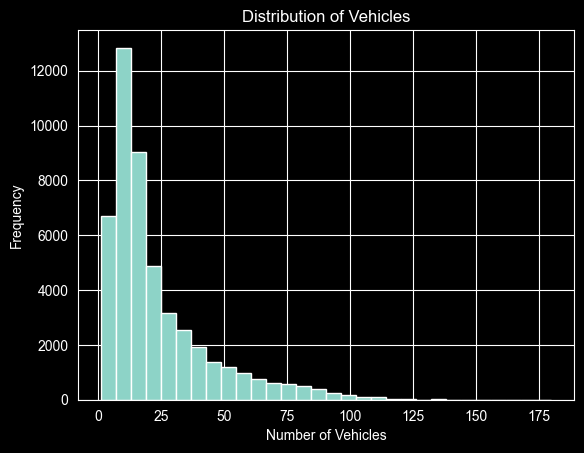

In [108]:
plt.hist(data['Vehicles'], bins=30)
plt.xlabel('Number of Vehicles')
plt.ylabel('Frequency')
plt.title('Distribution of Vehicles')
plt.show()


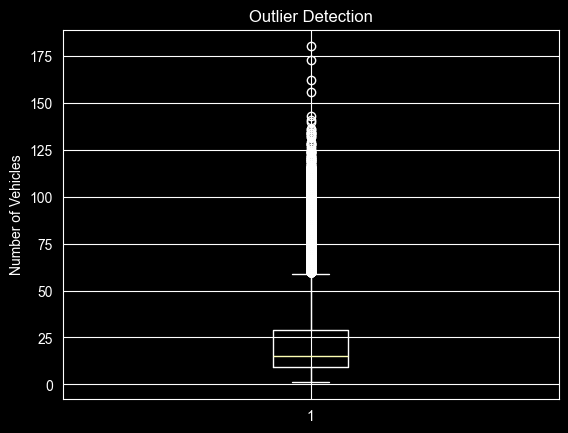

In [109]:
plt.boxplot(data['Vehicles'])
plt.ylabel('Number of Vehicles')
plt.title('Outlier Detection')
plt.show()

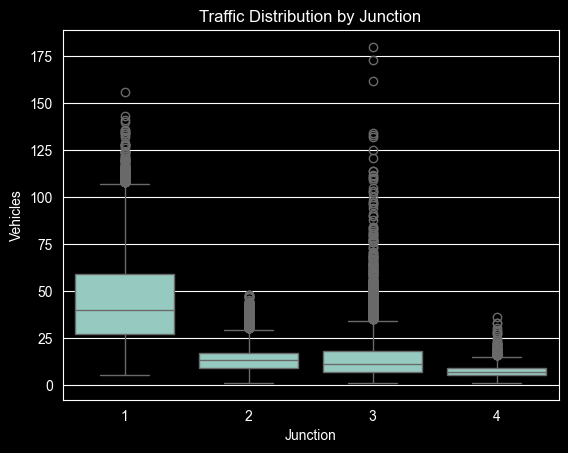

In [110]:
sns.boxplot(x='Junction', y='Vehicles', data=data)
plt.title('Traffic Distribution by Junction')
plt.show()

In [111]:
data['Date'] = pd.to_datetime(data['Date'])
data['Time'] = pd.to_datetime(data['Time'], format='%H:%M:%S').dt.hour

In [112]:
data.head()

,Junction,Vehicles,ID,Date,Time
0,1,15,20151101001,2015-11-01,0
1,1,13,20151101011,2015-11-01,1
2,1,10,20151101021,2015-11-01,2
3,1,7,20151101031,2015-11-01,3
4,1,9,20151101041,2015-11-01,4


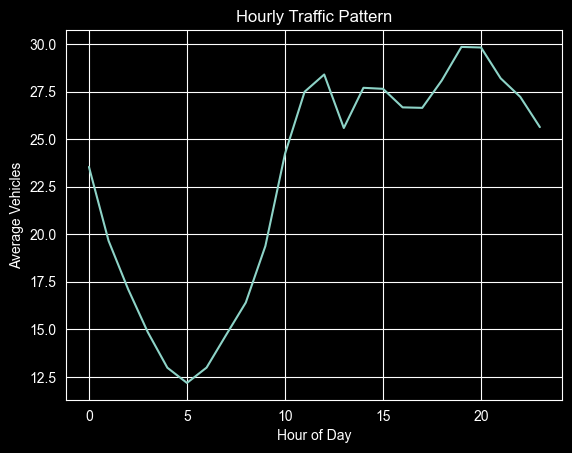

In [113]:
hourly_avg = data.groupby('Time')['Vehicles'].mean()
plt.plot(hourly_avg.index, hourly_avg.values)
plt.xlabel('Hour of Day')
plt.ylabel('Average Vehicles')
plt.title('Hourly Traffic Pattern')
plt.show()

In [114]:
data.drop(['ID'],axis=1,inplace=True)

In [115]:
data=pd.get_dummies(data,columns=['Junction'],drop_first=True)

In [116]:
data

,Vehicles,Date,Time,Junction_2,Junction_3,Junction_4
0,15,2015-11-01,0,False,False,False
1,13,2015-11-01,1,False,False,False
2,10,2015-11-01,2,False,False,False
3,7,2015-11-01,3,False,False,False
4,9,2015-11-01,4,False,False,False
...,...,...,...,...,...,...
48115,11,2017-06-30,19,False,False,True
48116,30,2017-06-30,20,False,False,True
48117,16,2017-06-30,21,False,False,True
48118,22,2017-06-30,22,False,False,True


In [117]:
x=data.drop(['Vehicles'],axis=1)
y=data['Vehicles']

In [118]:
x

,Date,Time,Junction_2,Junction_3,Junction_4
0,2015-11-01,0,False,False,False
1,2015-11-01,1,False,False,False
2,2015-11-01,2,False,False,False
3,2015-11-01,3,False,False,False
4,2015-11-01,4,False,False,False
...,...,...,...,...,...
48115,2017-06-30,19,False,False,True
48116,2017-06-30,20,False,False,True
48117,2017-06-30,21,False,False,True
48118,2017-06-30,22,False,False,True


In [119]:
y

0        15
1        13
2        10
3         7
4         9
         ..
48115    11
48116    30
48117    16
48118    22
48119    12
Name: Vehicles, Length: 48120, dtype: int64

In [120]:
from sklearn.model_selection import train_test_split

In [121]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [122]:
from sklearn.linear_model import LinearRegression

In [125]:
x_train.dtypes

Date          datetime64[s]
Time                  int32
Junction_2             bool
Junction_3             bool
Junction_4             bool
dtype: object

In [126]:
data['Date']=pd.to_datetime(data['Date'])
data['Day']=data['Date'].dt.day
data['Month']=data['Date'].dt.month
data['Year']=data['Date'].dt.year


In [127]:
data

,Vehicles,Date,Time,Junction_2,Junction_3,Junction_4,Day,Month,Year
0,15,2015-11-01,0,False,False,False,1,11,2015
1,13,2015-11-01,1,False,False,False,1,11,2015
2,10,2015-11-01,2,False,False,False,1,11,2015
3,7,2015-11-01,3,False,False,False,1,11,2015
4,9,2015-11-01,4,False,False,False,1,11,2015
...,...,...,...,...,...,...,...,...,...
48115,11,2017-06-30,19,False,False,True,30,6,2017
48116,30,2017-06-30,20,False,False,True,30,6,2017
48117,16,2017-06-30,21,False,False,True,30,6,2017
48118,22,2017-06-30,22,False,False,True,30,6,2017


In [128]:
data.drop(['Date'],axis=1,inplace=True)

In [130]:
x=data.drop(['Vehicles'],axis=1)
y=data['Vehicles']

In [131]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [132]:
LRmodel=LinearRegression()

In [133]:
LRmodel.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [134]:
y_pred=LRmodel.predict(x_test)

In [138]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
print("Linear Regression MAE:",mean_absolute_error(y_test, y_pred))
print("Linear Regression RMSE:",np.sqrt(mean_squared_error(y_test,y_pred)))

Linear Regression MAE: 8.086303119365951
Linear Regression RMSE: 11.225254114107376


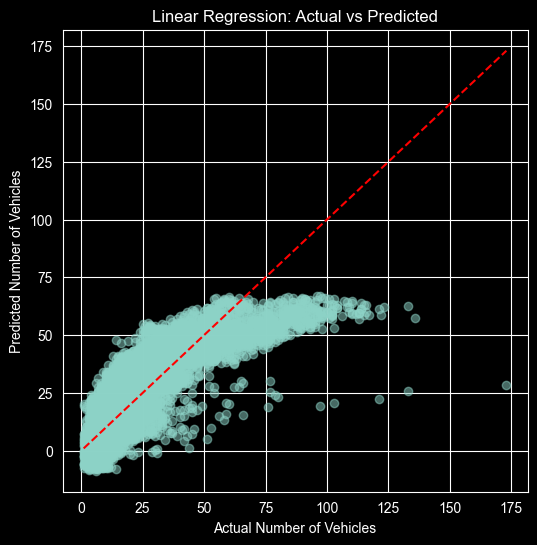

In [139]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Number of Vehicles")
plt.ylabel("Predicted Number of Vehicles")
plt.title("Linear Regression: Actual vs Predicted")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')

plt.show()

In [141]:
lr_score=LRmodel.score(x_test,y_test)
lr_score

0.6908174784854193

In [142]:
import pickle

In [143]:
with open("linear_regression_traffic.pkl","wb") as file:
    pickle.dump(LRmodel,file)

In [145]:
x_train.columns

Index(['Time', 'Junction_2', 'Junction_3', 'Junction_4', 'Day', 'Month',
       'Year'],
      dtype='str')